# GMP 3779



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

import glob
import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

from pangal.pangal import PanGal
from pangal.region import Region
from pangal.plot import Point, Contours
from pangal.photometry_table import PhotometryTable, PhotometryCatalog

import warnings
warnings.simplefilter("ignore")


In [2]:

directory = '../DATA/Coma/GMP3779/FITS_OBS/'
muse_file =  glob.glob(directory+'*muse*.fits')
spitzer_files = glob.glob(directory+'*SPITZER_*.fits')
sdss_files = glob.glob(directory+'*sdss*.fits')
wise_files = glob.glob(directory+'*WISE*.fits')
hershel_files = ['../DATA/Coma/hpacs_Coma_full_70u.fits',
                '../DATA/Coma/hpacs_Coma_full_100u.fits',
                '../DATA/Coma/hpacs_Coma_full_160u.fits']
twomass_files = glob.glob(directory+'*2mass*.fits')
hst_files = glob.glob(directory+'*hst*.fits')
galex_files = ['../DATA/Coma/galex_Coma_coadd-int_nuv.fits','../DATA/Coma/galex_Coma_coadd-int_fuv.fits']

files_list =  galex_files + sdss_files + spitzer_files + hershel_files + muse_file +hst_files #+ wise_files
print(files_list)


['../DATA/Coma/galex_Coma_coadd-int_nuv.fits', '../DATA/Coma/galex_Coma_coadd-int_fuv.fits', '../DATA/Coma/GMP3779/FITS_OBS/sdss_u.fits', '../DATA/Coma/GMP3779/FITS_OBS/sdss_i.fits', '../DATA/Coma/GMP3779/FITS_OBS/sdss_g.fits', '../DATA/Coma/GMP3779/FITS_OBS/sdss_r.fits', '../DATA/Coma/GMP3779/FITS_OBS/sdss_z.fits', '../DATA/Coma/GMP3779/FITS_OBS/SPITZER_IRAC1.fits', '../DATA/Coma/GMP3779/FITS_OBS/SPITZER_IRAC4.fits', '../DATA/Coma/GMP3779/FITS_OBS/SPITZER_IRAC2.fits', '../DATA/Coma/GMP3779/FITS_OBS/SPITZER_IRAC3.fits', '../DATA/Coma/hpacs_Coma_full_70u.fits', '../DATA/Coma/hpacs_Coma_full_100u.fits', '../DATA/Coma/hpacs_Coma_full_160u.fits', '../DATA/Coma/GMP3779/FITS_OBS/GMP3779_muse.fits', '../DATA/Coma/GMP3779/FITS_OBS/hst_f350lp.fits', '../DATA/Coma/GMP3779/FITS_OBS/hst_f600lp.fits']


In [3]:
ra_center, dec_center = 194.7720122, 27.6443910
z_true = 0.0181 # actual redshift (galaxy has a proper motion within the cluster)
distance = 	100 # Mpc (Hubble distance)


In [4]:
galaxy = PanGal(fits_files=files_list,target_coords = [ra_center,dec_center], fov=1/12,EBmV=0.0093, EBmV_err=0.0002)


Processing GALEX file:  ../DATA/Coma/galex_Coma_coadd-int_nuv.fits
Processing GALEX file:  ../DATA/Coma/galex_Coma_coadd-int_fuv.fits
Processing SDSS file:  ../DATA/Coma/GMP3779/FITS_OBS/sdss_u.fits
Processing SDSS file:  ../DATA/Coma/GMP3779/FITS_OBS/sdss_i.fits
Processing SDSS file:  ../DATA/Coma/GMP3779/FITS_OBS/sdss_g.fits
Processing SDSS file:  ../DATA/Coma/GMP3779/FITS_OBS/sdss_r.fits
Processing SDSS file:  ../DATA/Coma/GMP3779/FITS_OBS/sdss_z.fits
Processing IRAC:  ../DATA/Coma/GMP3779/FITS_OBS/SPITZER_IRAC1.fits
Processing IRAC:  ../DATA/Coma/GMP3779/FITS_OBS/SPITZER_IRAC4.fits
Processing IRAC:  ../DATA/Coma/GMP3779/FITS_OBS/SPITZER_IRAC2.fits
Processing IRAC:  ../DATA/Coma/GMP3779/FITS_OBS/SPITZER_IRAC3.fits
Processing Herschel PACS:  ../DATA/Coma/hpacs_Coma_full_70u.fits
Processing Herschel PACS:  ../DATA/Coma/hpacs_Coma_full_100u.fits
Processing Herschel PACS:  ../DATA/Coma/hpacs_Coma_full_160u.fits
Processing MUSE:  ../DATA/Coma/GMP3779/FITS_OBS/GMP3779_muse.fits
Correcting

In [8]:
print(galaxy.images.keys())
print(repr(galaxy.images.hst_wfc3_uvis_f350lp.header['EXPTIME']))
print(repr(galaxy.images.hst_wfc3_uvis_f600lp.header['EXPTIME']))

dict_keys(['galex_nuv', 'galex_fuv', 'sdss_u', 'sdss_i', 'sdss_g', 'sdss_r', 'sdss_z', 'spitzer_irac_1', 'spitzer_irac_4', 'spitzer_irac_2', 'spitzer_irac_3', 'herschel_pacs_70um', 'herschel_pacs_100um', 'herschel_pacs_160um', 'muse_blue', 'muse_green', 'muse_red', 'muse_nir', 'muse_white_aoe', 'hst_wfc3_uvis_f350lp', 'hst_wfc3_uvis_f600lp', 'muse_Ha', 'muse_Hb'])
2085.0
2919.0


In [9]:
for line in ['Ha','Hb']:
    base_name = f"{galaxy.cubes.muse.id}_{line}"
    image_name = base_name
    i = 1
    while image_name in galaxy.images:
        image_name = f"{base_name}({i})"
        i += 1
    
    # Save
    galaxy.images[image_name] = galaxy.cubes.muse.line_map(line=line, width=10, continuum_offset_1=50, continuum_offset_2=50, z=z_true)


In [10]:
# OFFSET BETWEEN MUSE and the other bands
galaxy.correct_coords_offset('muse', offset=(+0.0006,0))
#New CRVAL: [np.float64(194.76927000000003), np.float64(27.643830000000005)]


muse_Ha CRVAL updated by offset (RA: 0.0006 deg, Dec: 0 deg). Old CRVAL: [194.76863  27.64403] New CRVAL: [194.76863000000003, 27.64403]
muse_red CRVAL updated by offset (RA: 0.0006 deg, Dec: 0 deg). Old CRVAL: [194.76863  27.64403] New CRVAL: [194.76863000000003, 27.64403]
muse_blue CRVAL updated by offset (RA: 0.0006 deg, Dec: 0 deg). Old CRVAL: [194.76863  27.64403] New CRVAL: [194.76863000000003, 27.64403]
muse_Hb(1) CRVAL updated by offset (RA: 0.0006 deg, Dec: 0 deg). Old CRVAL: [194.76863  27.64403] New CRVAL: [194.76863000000003, 27.64403]
muse_green CRVAL updated by offset (RA: 0.0006 deg, Dec: 0 deg). Old CRVAL: [194.76863  27.64403] New CRVAL: [194.76863000000003, 27.64403]
muse CRVAL updated by offset (RA: 0.0006 deg, Dec: 0 deg). Old CRVAL: [194.76863  27.64403] New CRVAL: [194.76863000000003, 27.64403]
muse_Hb CRVAL updated by offset (RA: 0.0006 deg, Dec: 0 deg). Old CRVAL: [194.76863  27.64403] New CRVAL: [194.76863000000003, 27.64403]
muse_nir CRVAL updated by offset (R

In [8]:
#galaxy.correct_coords_offset('galex', offset=(0,+0.0002))
#New CRVAL: [np.float64(195.0532528935), np.float64(27.86163255741)]

In [9]:
#galaxy.correct_coords_offset('herschel', offset=(0,+0.0001))
#New CRVAL: [np.float64(193.5899304738718), np.float64(26.536945884594594)]

In [11]:


image_obj = galaxy.images['muse_red']

# Convert angular scale to physical scale
from astropy.cosmology import Planck18 as cosmo
z_Coma = 0.023513
D_A = cosmo.angular_diameter_distance(z_Coma).to('pc').value
theta_deg_1kpc = 1e3 / D_A / (np.pi / 180)               # Convert 1 kpc in deg
theta_arcsec_1kpc = 1e3 / D_A / (np.pi / 648000)         # Convert 1 kpc in arcsec
npix_1kpc = theta_deg_1kpc / image_obj.dtheta_pix_deg    # number of pixels corresponding to 1 kpc

image = image_obj.mag_arcsec2

# Define the ellipse
x_center, y_center = image_obj.wcs.all_world2pix([[ra_center,dec_center]],1)[0] 
axis_ratio = 0.95
angle = -20

dr_pix = 3 * npix_1kpc

# Define the separator (regions must exclude Ha and Hb)
x_p, y_p = 114, 131
ra_x_p, dec_y_p = image_obj.wcs.all_pix2world([[y_p, x_p]], 0)[0]
m_semimajor_ax = np.tan(angle*np.pi/180)
m_sep_line = -1/m_semimajor_ax

angle_sep = 60
m_sep_line = np.tan(angle_sep*np.pi/180)

y_coords, x_coords = np.meshgrid(np.linspace(0,image.shape[0], image.shape[0]),np.linspace(0, image.shape[1], image.shape[1]),indexing='ij')
exclude_Ha_mask = (y_coords > m_sep_line * (x_coords - x_center) + y_center)


# REGIONS ARE DEFINED ON MUSE

regions_for_mcspf = []
from regions import EllipseAnnulusPixelRegion, PixCoord
from astropy import units as u


for i,r_kpc in enumerate(np.arange(3.5,10.5,2)):

    region = EllipseAnnulusPixelRegion(
        center=PixCoord(x_center, y_center),
        inner_width = 2 * r_kpc * npix_1kpc, 
        outer_width = 2 * (r_kpc+2) * npix_1kpc,  
        inner_height = axis_ratio * 2 * r_kpc * npix_1kpc,  
        outer_height = axis_ratio * 2 * (r_kpc+2) * npix_1kpc,
        angle = angle*u.deg  
    )

    mask_elliptical_annulus = region.to_mask(mode='center').to_image(image.shape).astype(bool)
    mask = np.zeros_like(image, dtype=bool)
    mask |= (mask_elliptical_annulus & exclude_Ha_mask.astype(bool))
    

    if np.any(mask):

        R = r_kpc + 1
        print(f'Average galactocentric radius region {i+1:.0f} = {R:.2f} kpc')
        x_centroid = x_center - R * npix_1kpc * np.cos(angle*np.pi/180)
        y_centroid = m_semimajor_ax * (x_centroid - x_center) + y_center 
        ra,dec = image_obj.wcs.all_pix2world([[x_centroid, y_centroid]], 0)[0]

        regions_for_mcspf.append(Region(mask=mask,wcs=image_obj.wcs,caption_coords = [ra,dec],id=str(i+1)))
        

Average galactocentric radius region 1 = 4.50 kpc
Average galactocentric radius region 2 = 6.50 kpc
Average galactocentric radius region 3 = 8.50 kpc
Average galactocentric radius region 4 = 10.50 kpc


In [12]:
ellipses = []
for R in [3,8]:
    ellipses.append(
        Region.ellipse(
            id=f'GMP 3779: R {R} kpc',
            ra_center=ra_center, dec_center=dec_center,
            semimajor_axis=R * theta_deg_1kpc,
            axis_ratio=axis_ratio, angle=angle,
            wcs=galaxy.images['muse_red'].wcs,
            image_shape=galaxy.images['muse_red'].mag_arcsec2.shape,
            linewidth=2, linestyle=':', color='yellow'
        )
    )

contours = [Contours(image=galaxy.images['muse_red'].mag_arcsec2,wcs=galaxy.images['muse_red'].wcs,levels=[22,23,24,25],
                     color='navy', linewidth=1.5,clabel_fontsize=12,clabel_fmt='%.0f',label='muse_red',), #target_bands=['muse_red']
           Contours(image=galaxy.images['muse_Ha'].erg_s_cm2_arcsec2,wcs=galaxy.images['muse_Ha'].wcs,levels=[5e-18,1e-16,1e-15],
                     color='pink', linewidth=1.5,clabel_fontsize=12,clabel_fmt='%.1e',label='Ha',)] #target_bands=['muse_Ha'] 


points=[Point(coords=(ra_center,dec_center),caption='IC 4040',caption_fontsize=14,caption_offset=[0.02,0.03],color='navy',)]


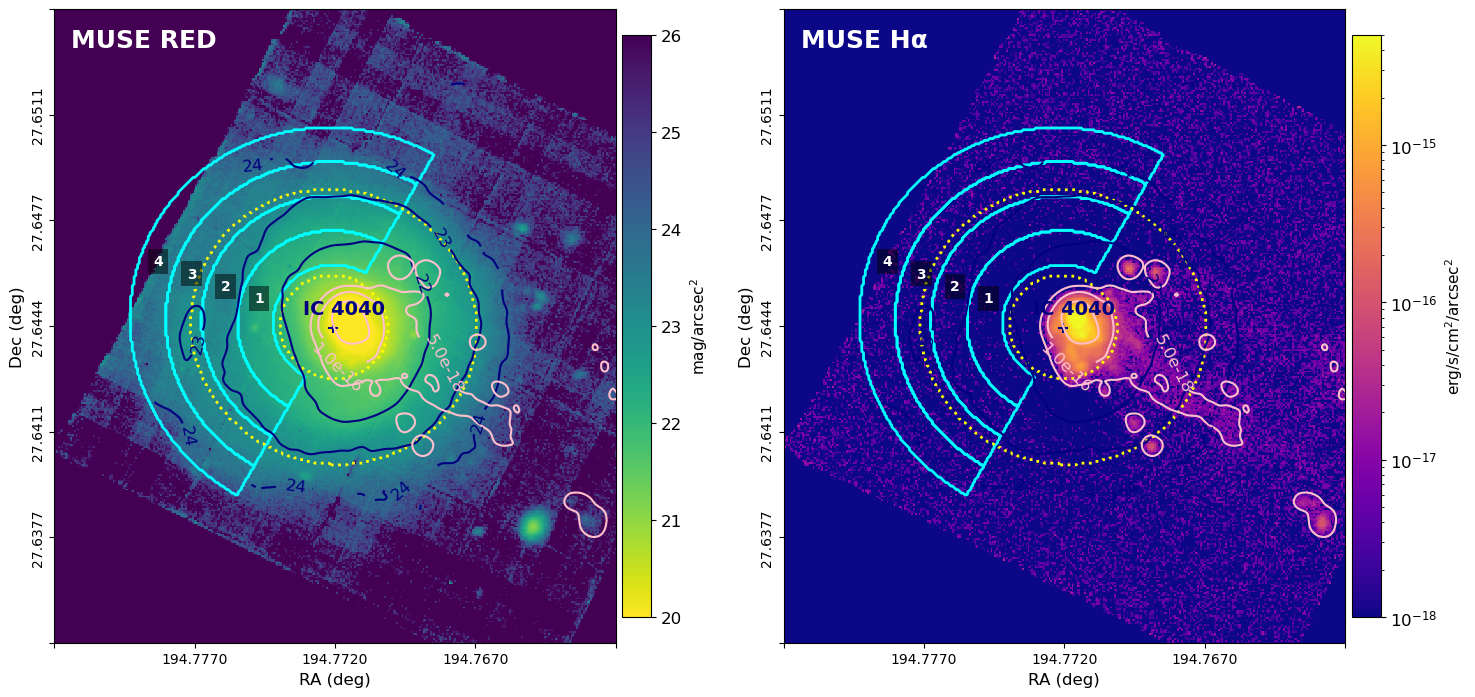

In [13]:


galaxy.plot( plots_per_row=2,
              
              bands=['muse_red','muse_Ha'],
              ra_min = ra_center-0.01,
              ra_max = ra_center+0.01,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,
              figsize= (15,10),
              auto_titles=True,
              auto_title_color='white',
              auto_title_fontsize=18,
                regions=regions_for_mcspf+ellipses, 
                contours=contours,
                points = points,
                set_scale_lims = {'muse_blue':(18,27),'muse_red':(20,26),'muse_Ha':(1e-18,5e-15)},
                set_cmaps = {'muse_red':'viridis','muse_Ha':'plasma','muse_Hb':'plasma'},
                legend=False,
                #n_yticks=3,
               show_region_captions=True,
                auto_titles_style=1,
                #interactive_pix_coords=True,
                n_xticks= 3,
                )


In [ ]:
contours[1].plot_aesthetic(color='red',linewidth=2)


galaxy.plot( plots_per_row=3,
            
              bands=['galex_fuv','galex_nuv','sdss_u','sdss_g','sdss_r','sdss_i','hst_wfc3_uvis_f600lp','hst_wfc3_uvis_f350lp','spitzer_irac_1',
                     'spitzer_irac_2','spitzer_irac_3','spitzer_irac_4',
                     'herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um'],
              auto_titles=True,
              auto_titles_style=1,
              auto_title_fontsize=20,
              auto_title_color='white',
              ra_min = ra_center-0.01,
              ra_max = ra_center+0.01,
              dec_min = dec_center-0.01,
              dec_max = dec_center+0.01,
              regions= regions_for_mcspf + ellipses,
              contours=[contours[1]],
              points = points,
              axis_label_fontsize=17,
              axis_ticks_fontsize=16,
              cbar_label_fontsize=18,
              cbar_ticks_fontsize=16,
              n_xticks=4,
              set_cmaps = {'galex_nuv':'plasma',
                           'galex_fuv':'magma',
                           'spitzer_irac_1':'bone',
                           'spitzer_irac_2':'pink',
                           'spitzer_irac_3':'copper',
                           'spitzer_irac_4':'gist_heat',
                           'herschel_pacs_70um':'GnBu_r',
                           'herschel_pacs_100um':'YlGn_r',
                           'herschel_pacs_160um':'OrRd_r',
                          },
              
              set_scale_lims = {#'galex_nuv':(22,27),
                                #'galex_fuv':(22,27),
                                #'spitzer_irac_3':(1,10),
                                #'spitzer_irac_4':(1,15),
                                'herschel_pacs_70um':(1,200),
                                'herschel_pacs_100um':(1,200),
                                'herschel_pacs_160um':(1,200),
                               
                               },
              show_region_captions=True,
              legend=False
            )



KeyError: 'herschel_pacs_70um'

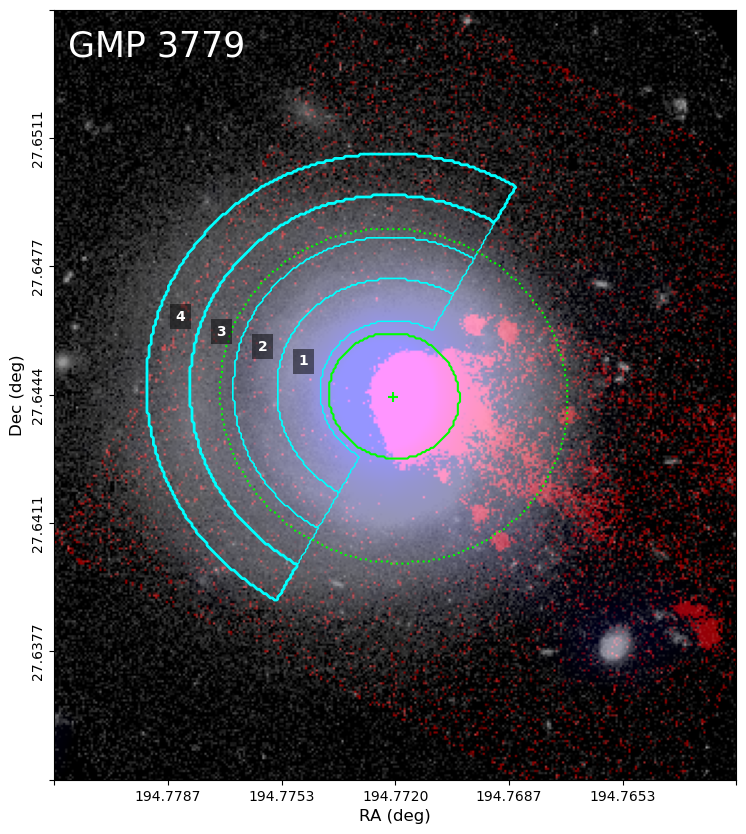

In [14]:
galaxy.make_false_color(
    bands=['muse_Ha','hst_wfc3_uvis_f350lp','galex_nuv'], #'spitzer_irac_1'],
    colors={
        'hst_wfc3_uvis_f350lp': (1,1,1),  # stellar continuum in white
        'muse_Ha':  (1,0,0),              # Hα in red
        'galex_nuv':(0,0,1),              # UV in blue
        'spitzer_irac_1': (0,1,0),
    },
    scale_lims={
        'hst_wfc3_uvis_f350lp': (30,95),  # adjust as needed to show stellar disc
        'muse_Ha':  (70,90),              # tweak to highlight Hα tails
        'galex_nuv':(70,99),             # highlight star-forming regions
        'spitzer_irac_1': (80,95),
    },
    stretch={
        'hst_wfc3_uvis_f350lp': 'log',  # smooth stellar light
        'muse_Ha':'asinh',                  # stretch faint Hα emission
        'galex_nuv':'asinh',                # stretch faint UV
        'spitzer_irac_1': 'asinh',
    },
    gamma=1.3
)

for i in range(3):
    regions_for_mcspf[i].plot_aesthetic(color='cyan',linewidth=1,caption_fontsize=10)
ellipses[0].plot_aesthetic(color='lime',linewidth=1.5,linestyle='-',caption_fontsize=10)
ellipses[1].plot_aesthetic(color='lime',linewidth=1.5,caption_fontsize=10)

p = Point(coords=(ra_center,dec_center),caption='',caption_fontsize=12,caption_offset=[0.02,0.03],color='lime',)

galaxy.plot_false_color(
    rgb_image='rgb',
    ra_min = ra_center-0.01,
    ra_max = ra_center+0.01,
    dec_min = dec_center-0.01,
    dec_max = dec_center+0.01,
    regions=regions_for_mcspf+ellipses,
    title='GMP 3779',
    title_loc=(0.15,0.93),
    title_fontsize=25,
    points=[p],
)

In [30]:
galaxy.images.keys()

dict_keys(['galex_nuv', 'galex_fuv', 'sdss_u', 'sdss_i', 'sdss_g', 'sdss_r', 'sdss_z', 'spitzer_irac_1', 'spitzer_irac_4', 'spitzer_irac_2', 'spitzer_irac_3', 'muse_blue', 'muse_green', 'muse_red', 'muse_nir', 'muse_white_aoe', 'hst_wfc3_uvis_f350lp', 'hst_wfc3_uvis_f600lp', 'muse_Ha', 'muse_Hb', 'rgb'])

In [27]:
bands = ['galex_nuv','galex_fuv','sdss_u', 'sdss_g','sdss_r', 'sdss_i', 'sdss_z', 'hst_wfc3_uvis_f350lp', 'hst_wfc3_uvis_f600lp',
         'spitzer_irac_1', 'spitzer_irac_2', 'spitzer_irac_3', 'spitzer_irac_4', 
         'herschel_pacs_70um', 'herschel_pacs_100um', 'herschel_pacs_160um']

phot_list = []
for i in range(4):
    phot = galaxy.photometry(regions_for_mcspf[i],background_exclude_regions=[ellipses[-1]],print_output=True,bands = bands)
    phot_list.append(phot)


GALEX NUV
Total flux: 1.15421, poisson unc: 0.00392, sky flux: 0.10372, sky std: 0.009492308143158813
	Flux = 0.03823 ± 0.00180 mJy, SNR = 21.21
GALEX FUV
Total flux: 0.12494, poisson unc: 0.00195, sky flux: 0.01100, sky std: 0.0018552452157874564
	Flux = 0.01313 ± 0.00068 mJy, SNR = 19.31
SDSS u
Total flux: 3222.24952, poisson unc: 7.61881, sky flux: 93.12050, sky std: 148.16586878436223
	Flux = 0.09152 ± 0.00550 mJy, SNR = 16.65
SDSS g
Total flux: 21462.61064, poisson unc: 19.90942, sky flux: 94.49593, sky std: 391.8330884286052
	Flux = 0.32909 ± 0.00676 mJy, SNR = 48.65
SDSS r
Total flux: 25369.39211, poisson unc: 21.63095, sky flux: 146.20099, sky std: 685.0621268670365
	Flux = 0.47255 ± 0.01356 mJy, SNR = 34.85
SDSS i
Total flux: 23357.26507, poisson unc: 20.76073, sky flux: 122.71639, sky std: 739.6713954310912
	Flux = 0.57716 ± 0.01914 mJy, SNR = 30.16
SDSS z
Total flux: 8266.76736, poisson unc: 12.32471, sky flux: 78.30208, sky std: 579.616793378233
	Flux = 0.63576 ± 0.04651 mJ

In [28]:
for i in range(3):
    for band in ['herschel_pacs_70um','herschel_pacs_100um','herschel_pacs_160um']:
        appo = phot_list[i].data[band]
        phot_list[i].data[band] = (0,appo[0])
    phot_list[i].to_fits(f'../DATA/Coma/GMP3779/gmp3779_region{i+1:.0f}_photometry.fits')

In [29]:
#galaxy.photometry(bands=['2mass_j'],regions=regions_for_mcspf,plot=True)

In [30]:
phot_list[0].print()

,Value,Error,SNR
galex_nuv,0.038228,0.001803,21.207448
galex_fuv,0.013132,0.000680,19.313301
sdss_u,0.091520,0.005496,16.652673
sdss_g,0.329086,0.006764,48.653558
sdss_r,0.472545,0.013560,34.847882
sdss_i,0.577162,0.019136,30.161518
sdss_z,0.635759,0.046511,13.669017
hst_wfc3_uvis_f350lp,0.391722,0.013919,28.142931
hst_wfc3_uvis_f600lp,0.540223,0.017590,30.711989
spitzer_irac_1,0.379175,0.012412,30.548470


In [31]:
spectra = galaxy.cubes.muse.extract_spectra(regions=regions_for_mcspf,pangal_object=galaxy)

In [32]:
for i,spec in enumerate(spectra):
    spec.header['REDSHIFT'] = z_true
    spec.to_fits(f'../DATA/Coma/GMP3779/spectra_extracted_from_MUSE/muse_spectrum_region_{i+1:.0f}.spec')

# FIT

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

import glob
import sys, os
sys.path.append(os.path.expanduser('~/Desktop/Pangal'))

#from pangal.pfitter import PFitter
from pangal.photometry_table import PhotometryTable

from pangal.pfitter import PFitter
from pangal.run import Run
#from build_boissier import load_spectrum_models_from_fits

import warnings
warnings.simplefilter("ignore")

In [36]:
phot = []
for i in range(3):
    phot.append(PhotometryTable().from_fits(f'../DATA/Coma/GMP3779/gmp3779_region{i+1:.0f}_photometry.fits'))

phot[0].print()

,Value,Error,SNR
galex_nuv,0.038228,0.001803,21.207448
galex_fuv,0.013132,0.000680,19.313301
sdss_u,0.091520,0.005496,16.652673
sdss_g,0.329086,0.006764,48.653558
sdss_r,0.472545,0.013560,34.847882
sdss_i,0.577162,0.019136,30.161518
sdss_z,0.635759,0.046511,13.669017
hst_wfc3_uvis_f350lp,0.391722,0.013919,28.142931
hst_wfc3_uvis_f600lp,0.540223,0.017590,30.711989
spitzer_irac_1,0.379175,0.012412,30.548470


In [37]:
from pangal.spectrum import Spectrum
spectra = []
for i in range(4):
    spectra.append(Spectrum().from_fits(f'../DATA/Coma/GMP3779/spectra_extracted_from_MUSE/muse_spectrum_region_{i+1:.0f}.spec'))

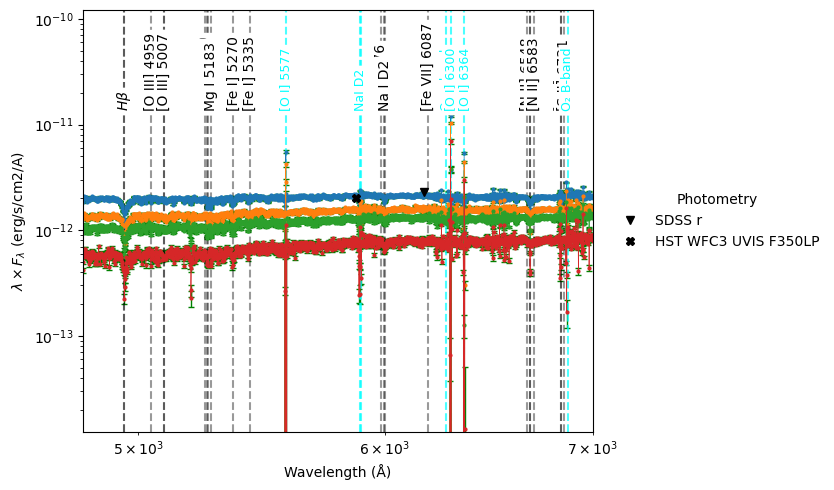

In [38]:
Spectrum().plot(figsize=(10,5),spectra=spectra, per_wavelength=True, phot=phot[0], #show_phot_legend=True,
              winf=4800,wsup=7000, 
                #ymin=5e-13, ymax= 1.5e-11, 
                #y_units='mJy',
                show_all_spectral_lines=True,show_top_spectral_lines=True,
                show_atmospheric_lines=True,show_spec_legend=False)


# Region 1

In [40]:
custom_prior = {
    'av':     {'type':'uniform', 'low':0.0,    'high':0.2},
    #'alpha':  {'type':'uniform', 'low':1.5,    'high':3},
    'm_star':  {'type':'uniform', 'low':8.2,    'high':9.5},
    'sigma_vel': {'type':'uniform', 'low':0,    'high':400},
    'vel_sys': {'type':'uniform', 'low':-500,    'high':+500},
    'TAU_Q': {'type':'uniform', 'low':10,    'high':500},
}

bands = ['galex_nuv','galex_fuv','sdss_u', 'sdss_g','sdss_r', 'sdss_i', 'sdss_z', 'hst_wfc3_uvis_f350lp', 'hst_wfc3_uvis_f600lp',
         'spitzer_irac_1', 'spitzer_irac_2', 'spitzer_irac_3', 'spitzer_irac_4', 
         'herschel_pacs_70um', 'herschel_pacs_100um', 'herschel_pacs_160um']



In [43]:
fitter = PFitter(model_file='../new_models/V_100_R_5.fit',
             model_pars=['Q_AGE','TAU_Q','BURST','METAL'],
             uv_bump = False,
             leitatt = False,
            )

Initializing PFitter object
Loading models from  ../new_models/V_100_R_5.fit
 Pre-computed model grid:
   - Q_AGE: 31 values, min=4, max=3000
   - TAU_Q: 28 values, min=2, max=2000
   - BURST: 1 values, min=0, max=0
   - METAL: 1 values, min=0.017, max=0.017


Dust attenuation curve from Calzetti 2000.
Loading nebular lines templates from  nebular_Byler_mist_2018.lines
 Emission line metallicity requested 0.0017, found 0.0020
Tabulated values for ionized gas age (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated values for ionization coefficient: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75  

In [45]:
res_spec_1 = fitter.run_fit(phot=phot[0], 
                            spec=spectra[0],
                            spectral_range=[4800,7000],
                     fix_pars={'ion_gas':-3.94,'age_gas':13,'redshift': 0.0181,'av_ext':0,'fesc':1,
                               'luminosity_distance':100,'BURST':0.0,'METAL':0.017},
                     nlive=100,
                     dlogz=0.1,
                     custom_priors=custom_prior,
                     )

Using the following photometric filters: galex_nuv, galex_fuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, hst_wfc3_uvis_f350lp, hst_wfc3_uvis_f600lp, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_100um, herschel_pacs_160um

Priors:
  - Q_AGE: Uniform(4, 3000)
  - TAU_Q: Uniform(10, 500)
  - av: Uniform(0.0, 0.2)
  - alpha: Uniform(0.0625, 4.0)
  - m_star: Uniform(8.2, 9.5)
  - vel_sys: Uniform(-500, 500)
  - sigma_vel: Uniform(0, 400)
  - spec_noise_scale: Gaussian(mean=0, sigma=4)
Initializing live points


2769it [08:41,  5.31it/s, +100 | bound: 406 | nc: 1 | ncall: 64610 | eff(%):  4.447 | loglstar:   -inf < 57766.433 <    inf | logz: 57741.199 +/-  0.476 | dlogz:  0.001 >  0.100]


In [48]:
res_spec_1.save('../DATA/Coma/GMP3779/dynesty_results/REGION_1_SPECPHOT.npz')

Saved fit results to ../DATA/Coma/GMP3779/dynesty_results/REGION_1_SPECPHOT.npz


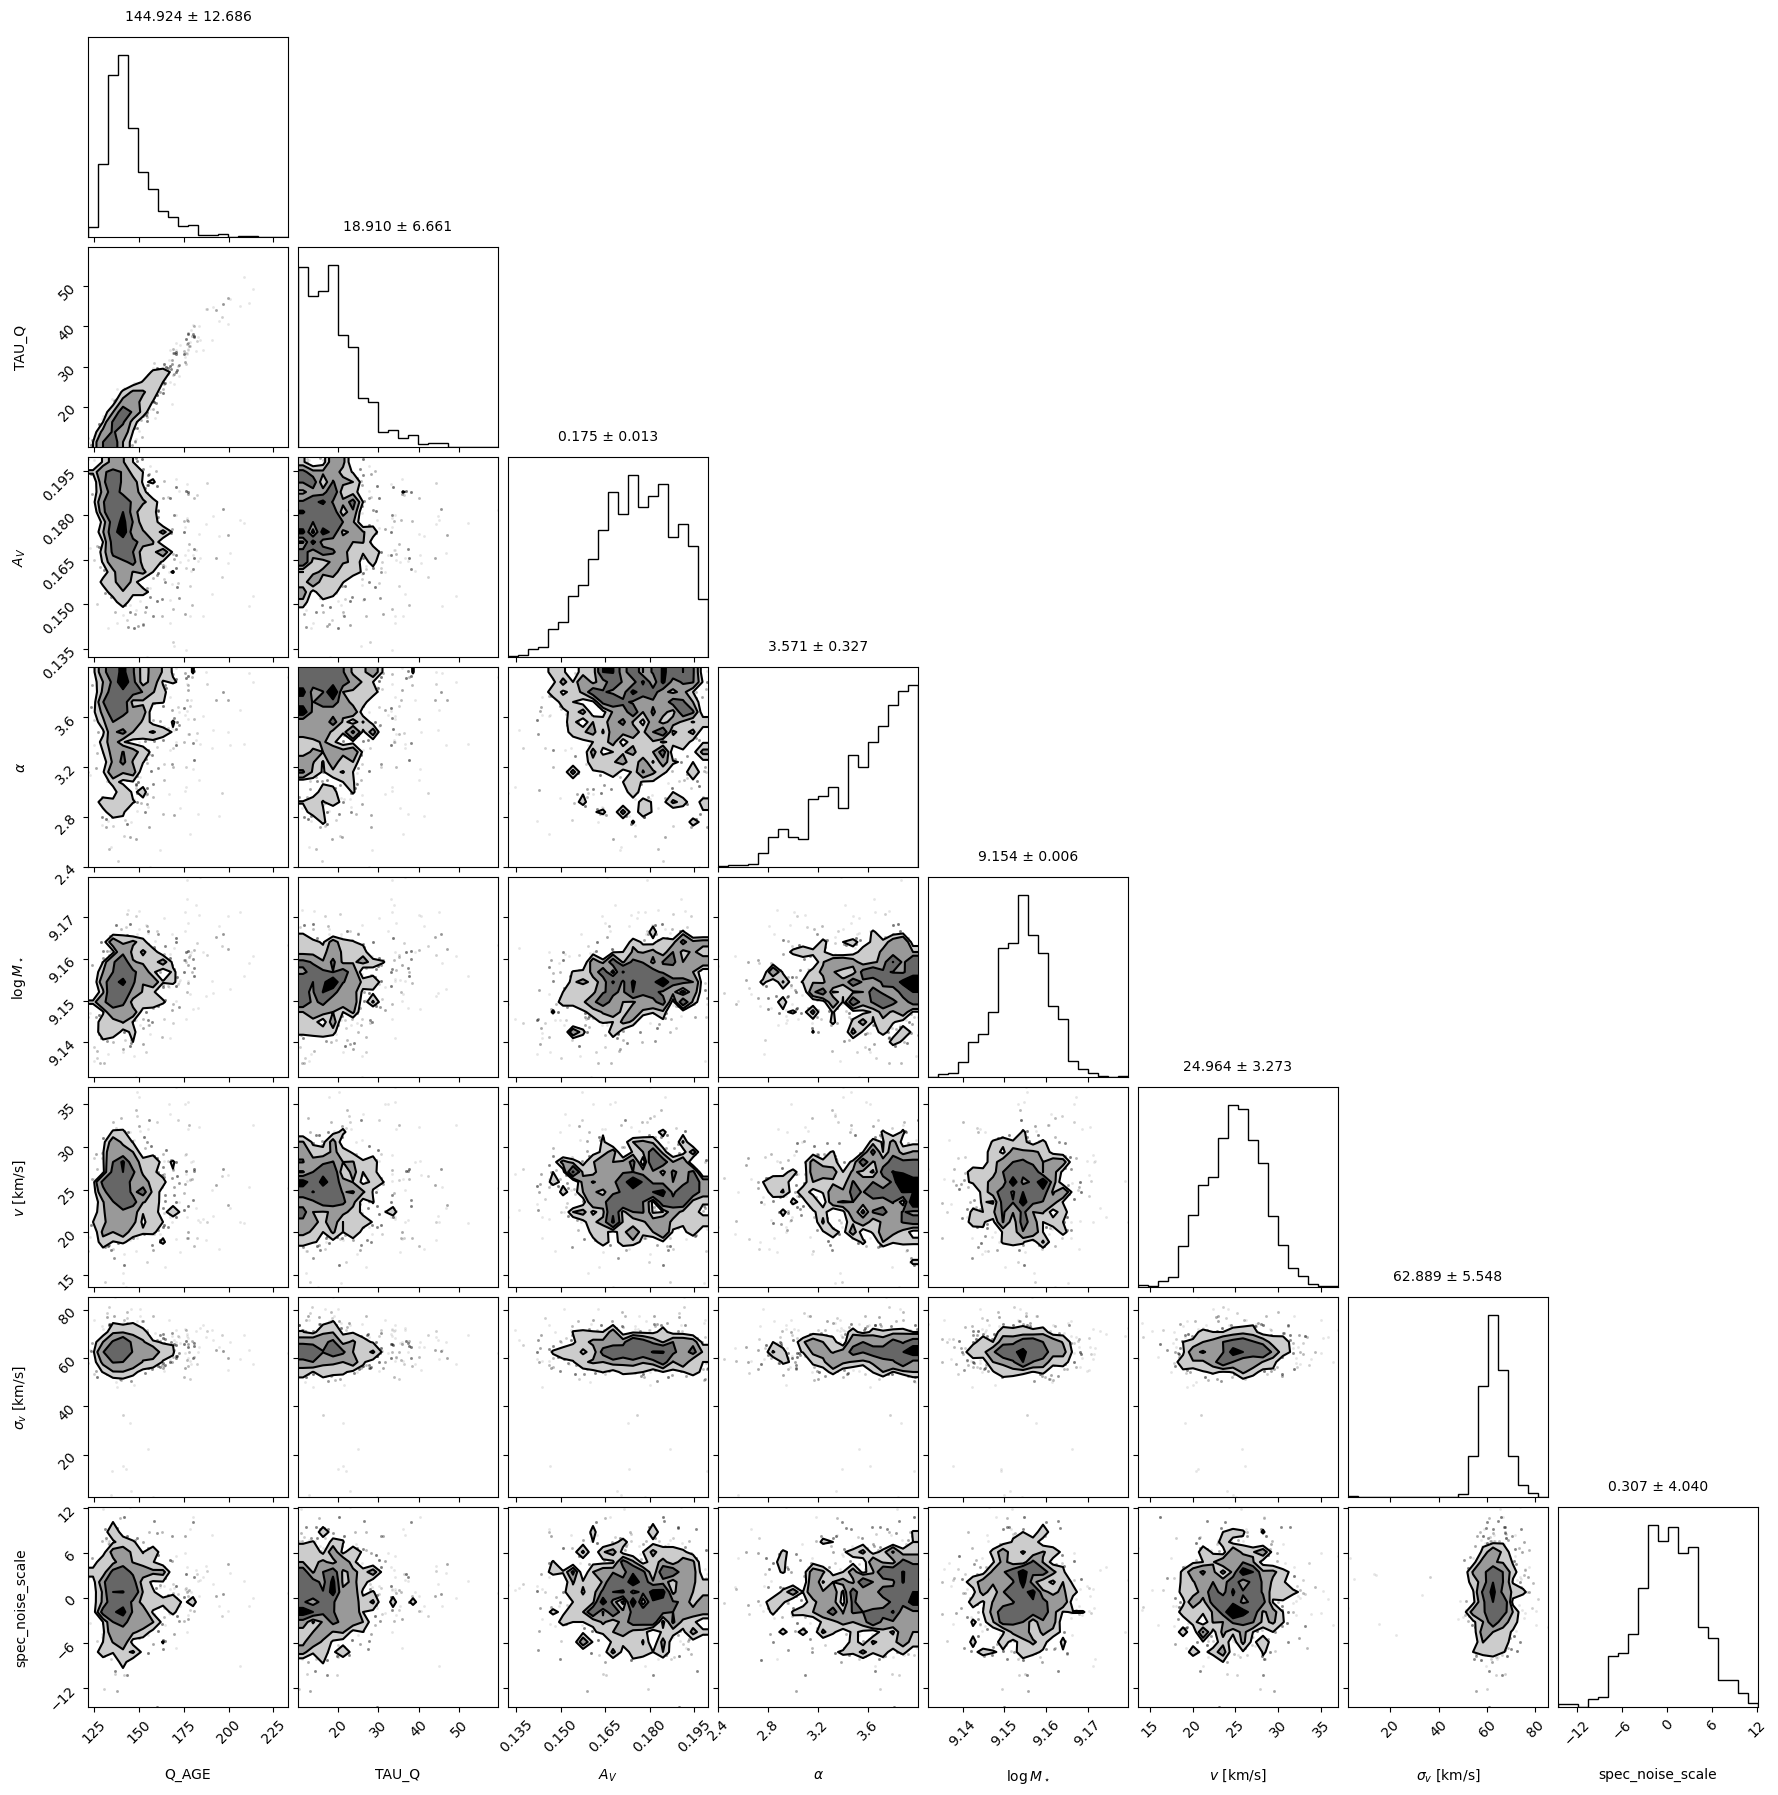

In [49]:
res_spec_1.cornerplot()

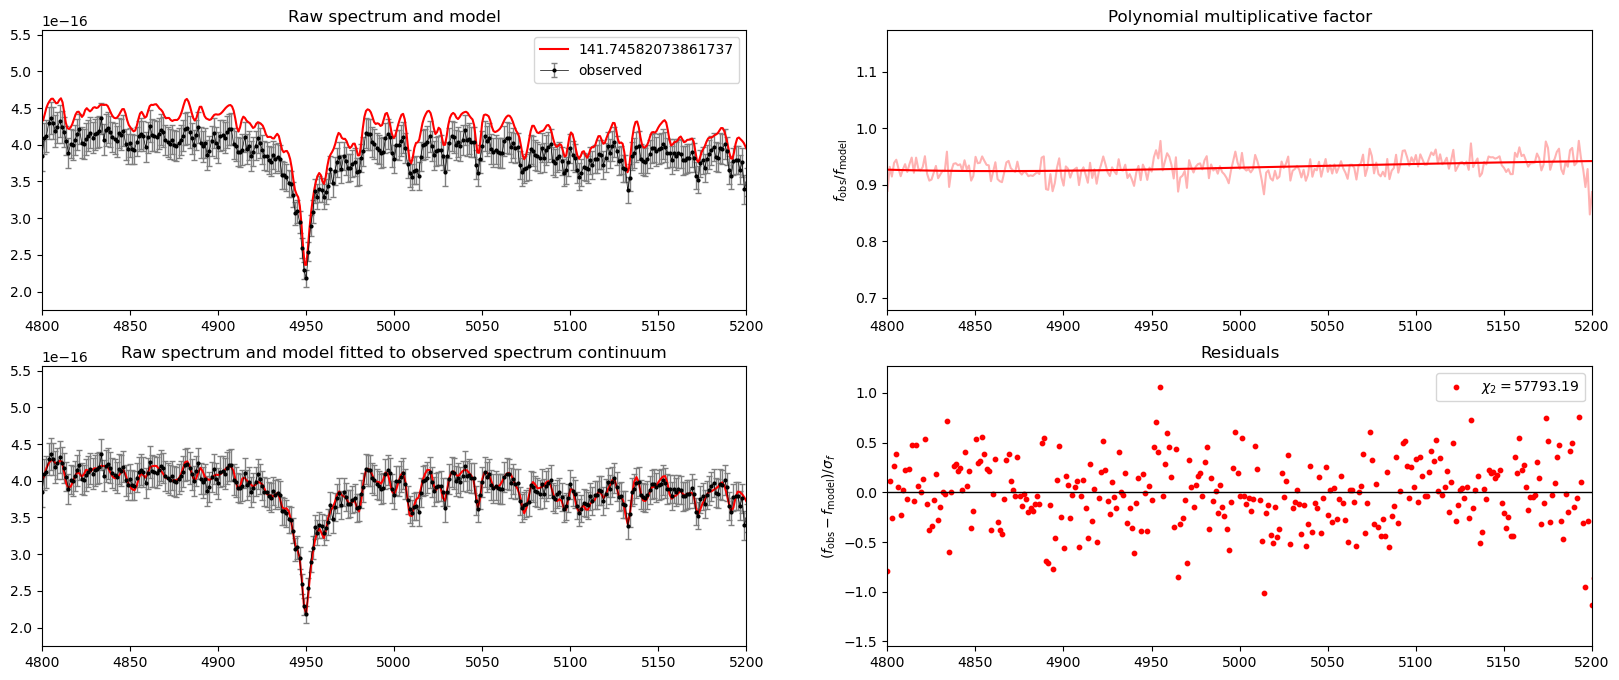

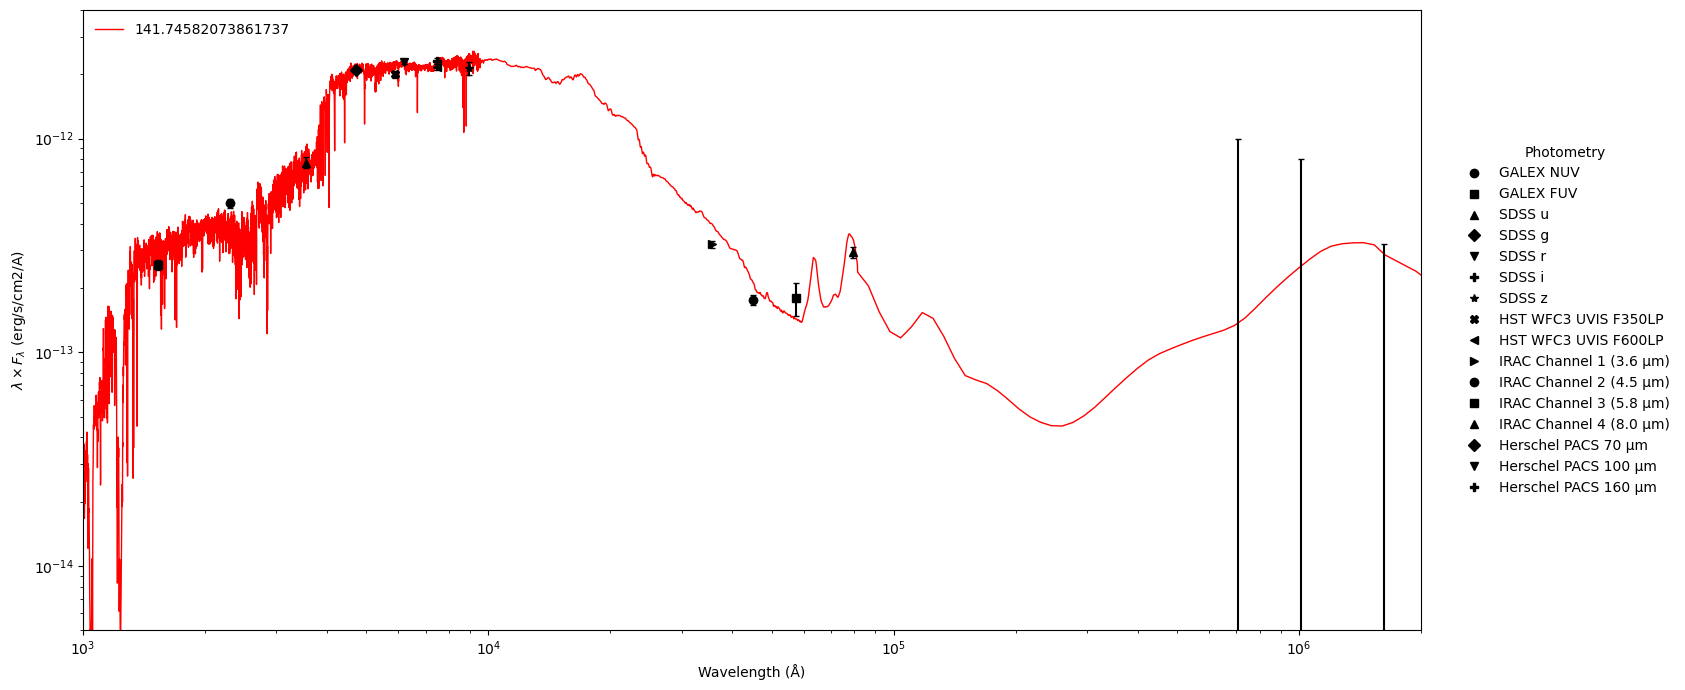

For model number:  1
GALEX NUV :  -8.360116959177287
GALEX FUV :  1.3388156676504126
SDSS u :  4.284492282923044
SDSS g :  -0.9005065774244434
SDSS r :  2.25708358092799
SDSS i :  2.477498200908153
SDSS z :  1.4544359195722585
HST WFC3 UVIS F350LP :  3.3507490926014842
HST WFC3 UVIS F600LP :  2.492458768163487
IRAC Channel 1 (3.6 μm) :  -24.396300415044927
IRAC Channel 2 (4.5 μm) :  -9.46491004146475
IRAC Channel 3 (5.8 μm) :  1.819793233770663
IRAC Channel 4 (8.0 μm) :  -8.335789586077079
Herschel PACS 70 μm  upper limit:  -0.813426685014182
Herschel PACS 100 μm  upper limit:  -0.9711366269603104
Herschel PACS 160 μm  upper limit:  -1.6895872112672519
TOTAL_PHOT:  -35.456447355912736
TOTAL_SPEC:  57793.18561571243
TOTAL_PHOT+SPEC:  57757.72916835651




In [50]:
res_spec_1.fit_diagnostic(method='MAP',
        cumulative=False,
        winf = 4800,wsup=5200,
        spec_legend_pars='Q_AGE',
        color=['red','cyan'],
        figsize=(20,8),
        winf_phot=1e3,wsup_phot=2e6,
        ymin=0.5e-14,ymax=4e-12,)

# Region 2

In [46]:
fitter = PFitter(model_file='../new_models/V_100_R_7.fit',
             model_pars=['Q_AGE','TAU_Q','BURST','METAL'],
             uv_bump = False,
             leitatt = False,
            )

Initializing PFitter object
Loading models from  ../new_models/V_100_R_7.fit
 Pre-computed model grid:
   - Q_AGE: 31 values, min=4, max=3000
   - TAU_Q: 28 values, min=2, max=2000
   - BURST: 1 values, min=0, max=0
   - METAL: 1 values, min=0.017, max=0.017


Dust attenuation curve from Calzetti 2000.
Loading nebular lines templates from  nebular_Byler_mist_2018.lines
 Emission line metallicity requested 0.0017, found 0.0020
Tabulated values for ionized gas age (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated values for ionization coefficient: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75  

In [54]:
res_spec_2 = fitter.run_fit(phot=phot[1], 
                            spec=spectra[1],
                            spectral_range=[4800,7000],
                     fix_pars={'ion_gas':-3.94,'age_gas':13,'redshift':0.0181,'av_ext':0,'fesc':1,
                               'luminosity_distance':100,'BURST':0.0,'METAL':0.017},
                     nlive=100,
                     dlogz=0.1,
                     custom_priors=custom_prior,
                     )

Using the following photometric filters: galex_nuv, galex_fuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, hst_wfc3_uvis_f350lp, hst_wfc3_uvis_f600lp, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_100um, herschel_pacs_160um

Priors:
  - Q_AGE: Uniform(4, 3000)
  - TAU_Q: Uniform(10, 500)
  - av: Uniform(0.0, 0.2)
  - alpha: Uniform(0.0625, 4.0)
  - m_star: Uniform(8.2, 9.5)
  - vel_sys: Uniform(-500, 500)
  - sigma_vel: Uniform(0, 400)
  - spec_noise_scale: Gaussian(mean=0, sigma=4)
Initializing live points


2434it [20:47,  1.95it/s, +100 | bound: 890 | nc: 1 | ncall: 137384 | eff(%):  1.846 | loglstar:   -inf < 58103.106 <    inf | logz: 58081.207 +/-    nan | dlogz:  0.001 >  0.100]


In [56]:
res_spec_2.save('../DATA/Coma/GMP3779/dynesty_results/REGION_2_SPECPHOT.npz')

Saved fit results to ../DATA/Coma/GMP3779/dynesty_results/REGION_2_SPECPHOT.npz


In [ ]:
res_spec_2 = Run().load('../DATA/Coma/GMP3779/dynesty_results/REGION_2_SPECPHOT.npz')

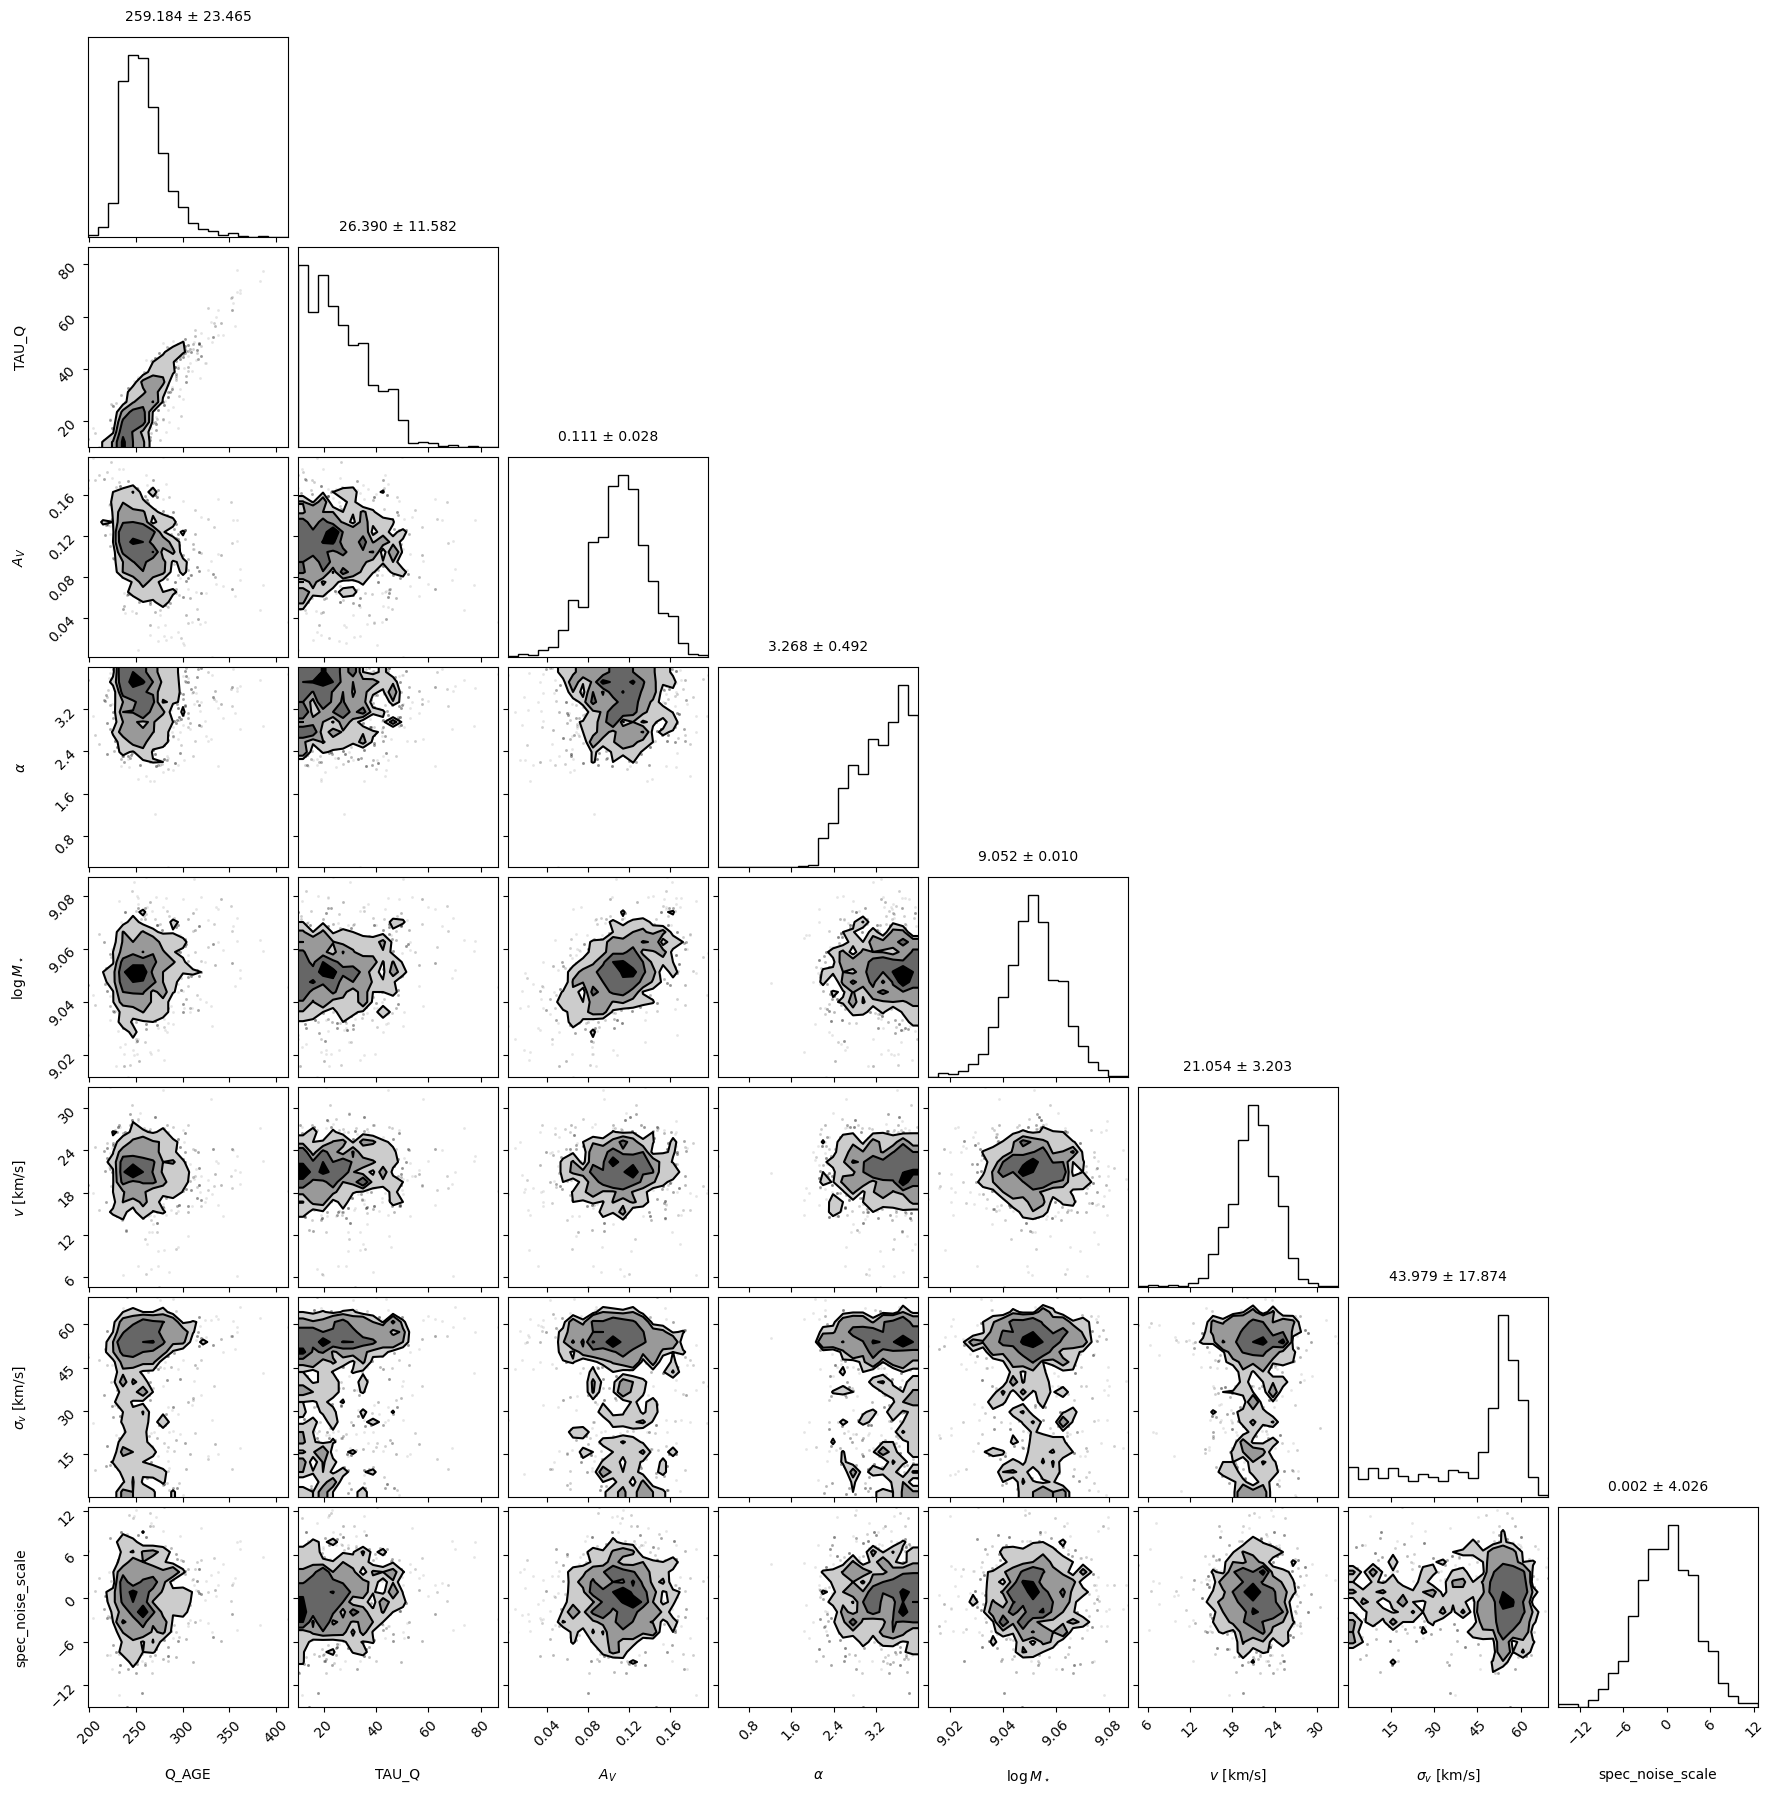

In [55]:
res_spec_2.cornerplot()

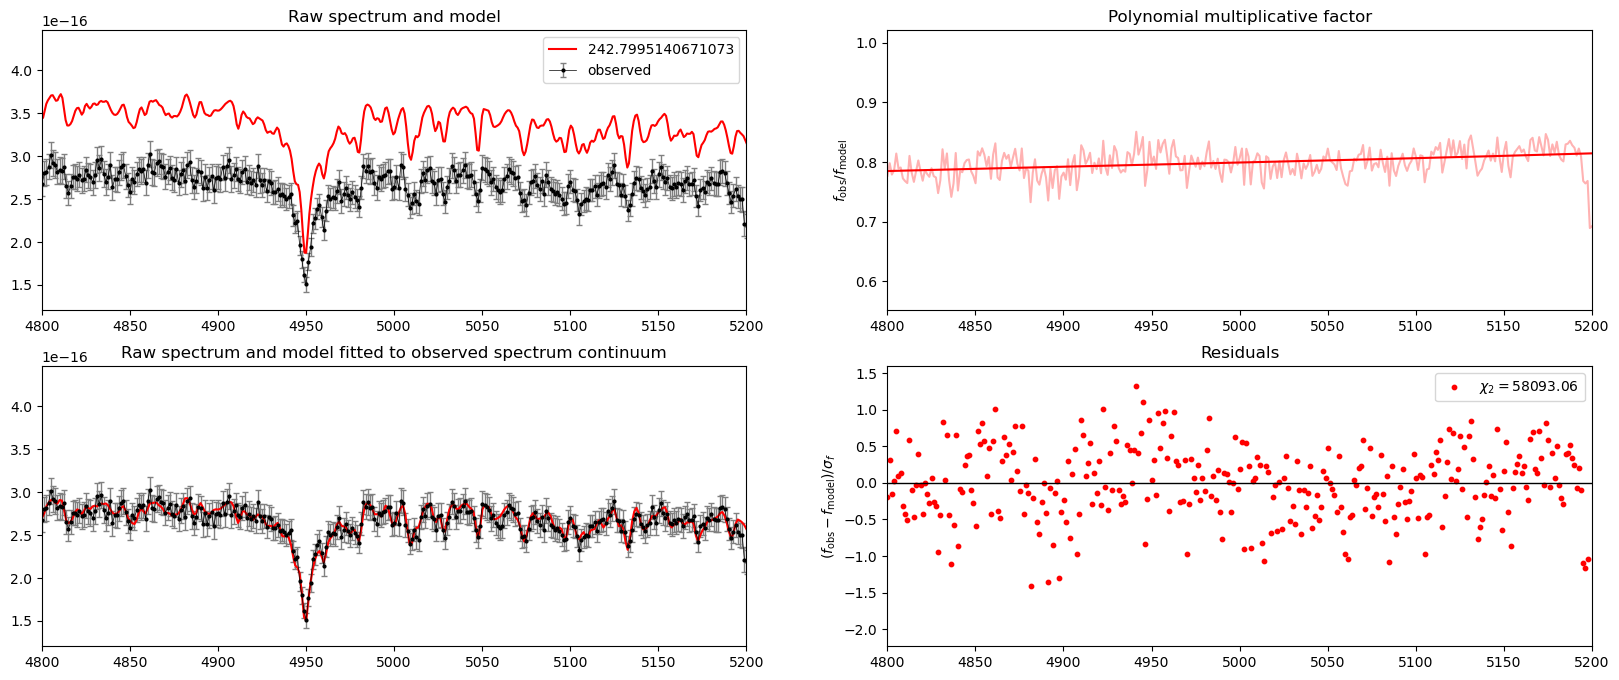

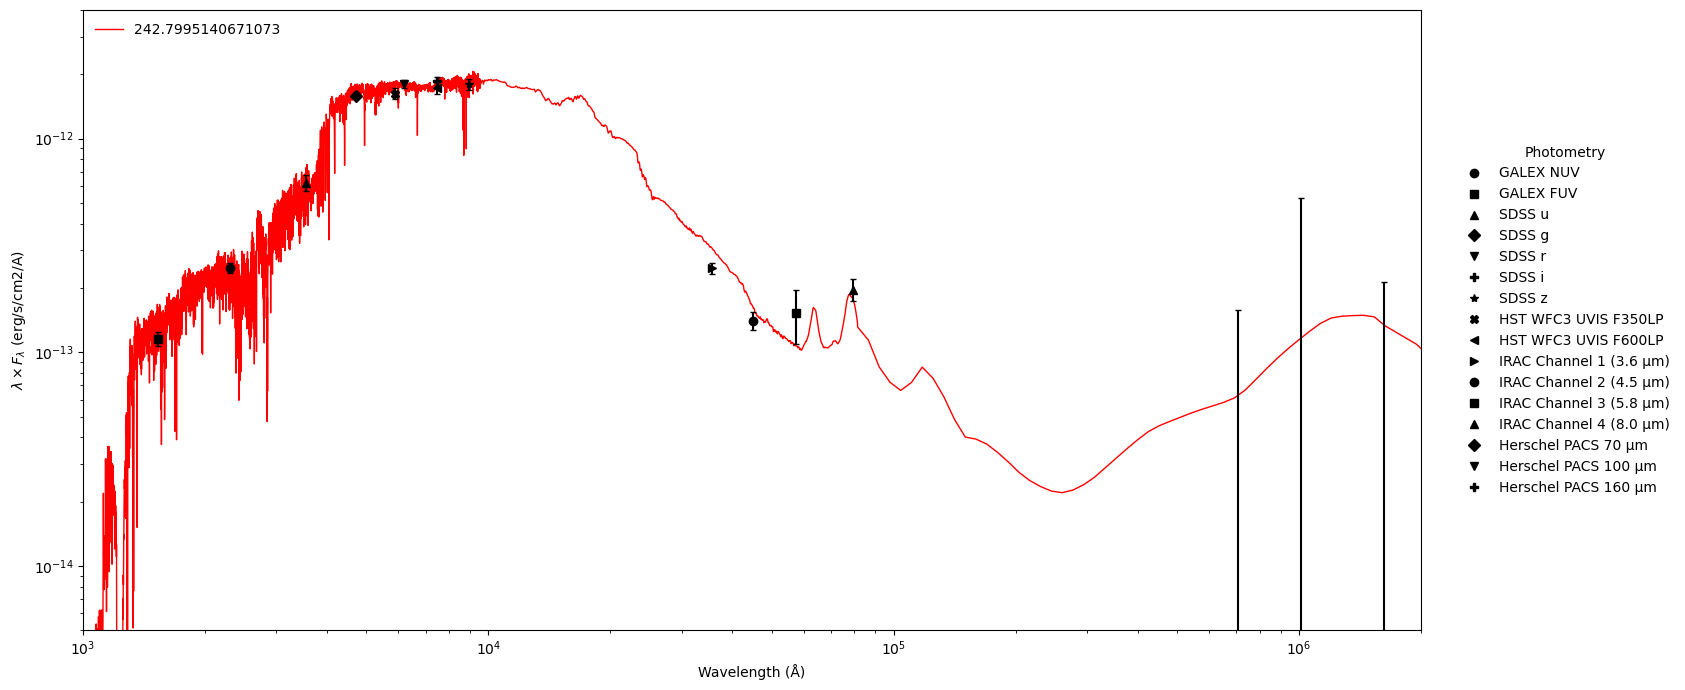

For model number:  1
GALEX NUV :  4.4720385956574376
GALEX FUV :  5.0549271670465465
SDSS u :  3.8762223366080857
SDSS g :  3.5556136504126554
SDSS r :  3.086113394830074
SDSS i :  2.6879705421665934
SDSS z :  2.3135181616509404
HST WFC3 UVIS F350LP :  2.964161077223667
HST WFC3 UVIS F600LP :  2.397393430802459
IRAC Channel 1 (3.6 μm) :  -5.572125518623659
IRAC Channel 2 (4.5 μm) :  -0.05651075500498415
IRAC Channel 3 (5.8 μm)  upper limit:  -0.25349889087693583
IRAC Channel 4 (8.0 μm) :  -2.993077722276161
Herschel PACS 70 μm  upper limit:  -1.0803322655727905
Herschel PACS 100 μm  upper limit:  -0.881263488631044
Herschel PACS 160 μm  upper limit:  -1.3254727409355178
TOTAL_PHOT:  18.245676974477366
TOTAL_SPEC:  58093.05534985663
TOTAL_PHOT+SPEC:  58111.301026831105




In [57]:
res_spec_2.fit_diagnostic(method='MAP',
        cumulative=False,
        winf = 4800,wsup=5200,
        spec_legend_pars='Q_AGE',
        color=['red','cyan'],
        figsize=(20,8),
        winf_phot=1e3,wsup_phot=2e6,
        ymin=0.5e-14,ymax=4e-12,)

# Region 3

In [58]:
fitter = PFitter(model_file='../new_models/V_100_R_9.fit',
             model_pars=['Q_AGE','TAU_Q','BURST','METAL'],
             uv_bump = False,
             leitatt = False,
            )


Initializing PFitter object
Loading models from  ../new_models/V_100_R_9.fit
 Pre-computed model grid:
   - Q_AGE: 31 values, min=4, max=3000
   - TAU_Q: 28 values, min=2, max=2000
   - BURST: 1 values, min=0, max=0
   - METAL: 1 values, min=0.017, max=0.017


Dust attenuation curve from Calzetti 2000.
Loading nebular lines templates from  nebular_Byler_mist_2018.lines
 Emission line metallicity requested 0.0017, found 0.0020
Tabulated values for ionized gas age (Myr): [ 0.5  1.   2.   3.   4.   5.   6.   7.  10. ]
Tabulated values for ionization coefficient: [-4.  -3.5 -3.  -2.5 -2.  -1.5 -1. ]
Loading of nebular lines templates completed.
Tabulated alpha values from 'alpha_dh02.dat': [0.0625 0.125  0.1875 0.25   0.3125 0.375  0.4375 0.5    0.5625 0.625
 0.6875 0.75   0.8125 0.875  0.9375 1.     1.0625 1.125  1.1875 1.25
 1.3125 1.375  1.4375 1.5    1.5625 1.625  1.6875 1.75   1.8125 1.875
 1.9375 2.     2.0625 2.125  2.1875 2.25   2.3125 2.375  2.4375 2.5
 2.5625 2.625  2.6875 2.75  

In [59]:
res_spec_3 = fitter.run_fit(phot=phot[2], 
                            spec=spectra[2],
                            spectral_range=[4800,7000],
                     fix_pars={'ion_gas':-3.94,'age_gas':13,'redshift':0.0181,'av_ext':0,'fesc':1,
                               'luminosity_distance':100,'BURST':0.0,'METAL':0.017},
                     nlive=100,
                     dlogz=0.1,
                     custom_priors=custom_prior,
                     )

Using the following photometric filters: galex_nuv, galex_fuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, hst_wfc3_uvis_f350lp, hst_wfc3_uvis_f600lp, spitzer_irac_1, spitzer_irac_2, spitzer_irac_3, spitzer_irac_4, herschel_pacs_70um, herschel_pacs_100um, herschel_pacs_160um

Priors:
  - Q_AGE: Uniform(4, 3000)
  - TAU_Q: Uniform(10, 500)
  - av: Uniform(0.0, 0.2)
  - alpha: Uniform(0.0625, 4.0)
  - m_star: Uniform(8.2, 9.5)
  - vel_sys: Uniform(-500, 500)
  - sigma_vel: Uniform(0, 400)
  - spec_noise_scale: Gaussian(mean=0, sigma=4)
Initializing live points


2137it [17:34,  2.03it/s, +100 | bound: 742 | nc: 1 | ncall: 114387 | eff(%):  1.957 | loglstar:   -inf < 58226.738 <    inf | logz: 58207.793 +/-    nan | dlogz:  0.001 >  0.100]


In [60]:
res_spec_3.save('../DATA/Coma/GMP3779/dynesty_results/REGION_3_SPECPHOT.npz')

Saved fit results to ../DATA/Coma/GMP3779/dynesty_results/REGION_3_SPECPHOT.npz


In [ ]:
#res_spec_3 = Run().load('../DATA/Coma/GMP3779/dynesty_results/REGION_3_SPECPHOT.npz')

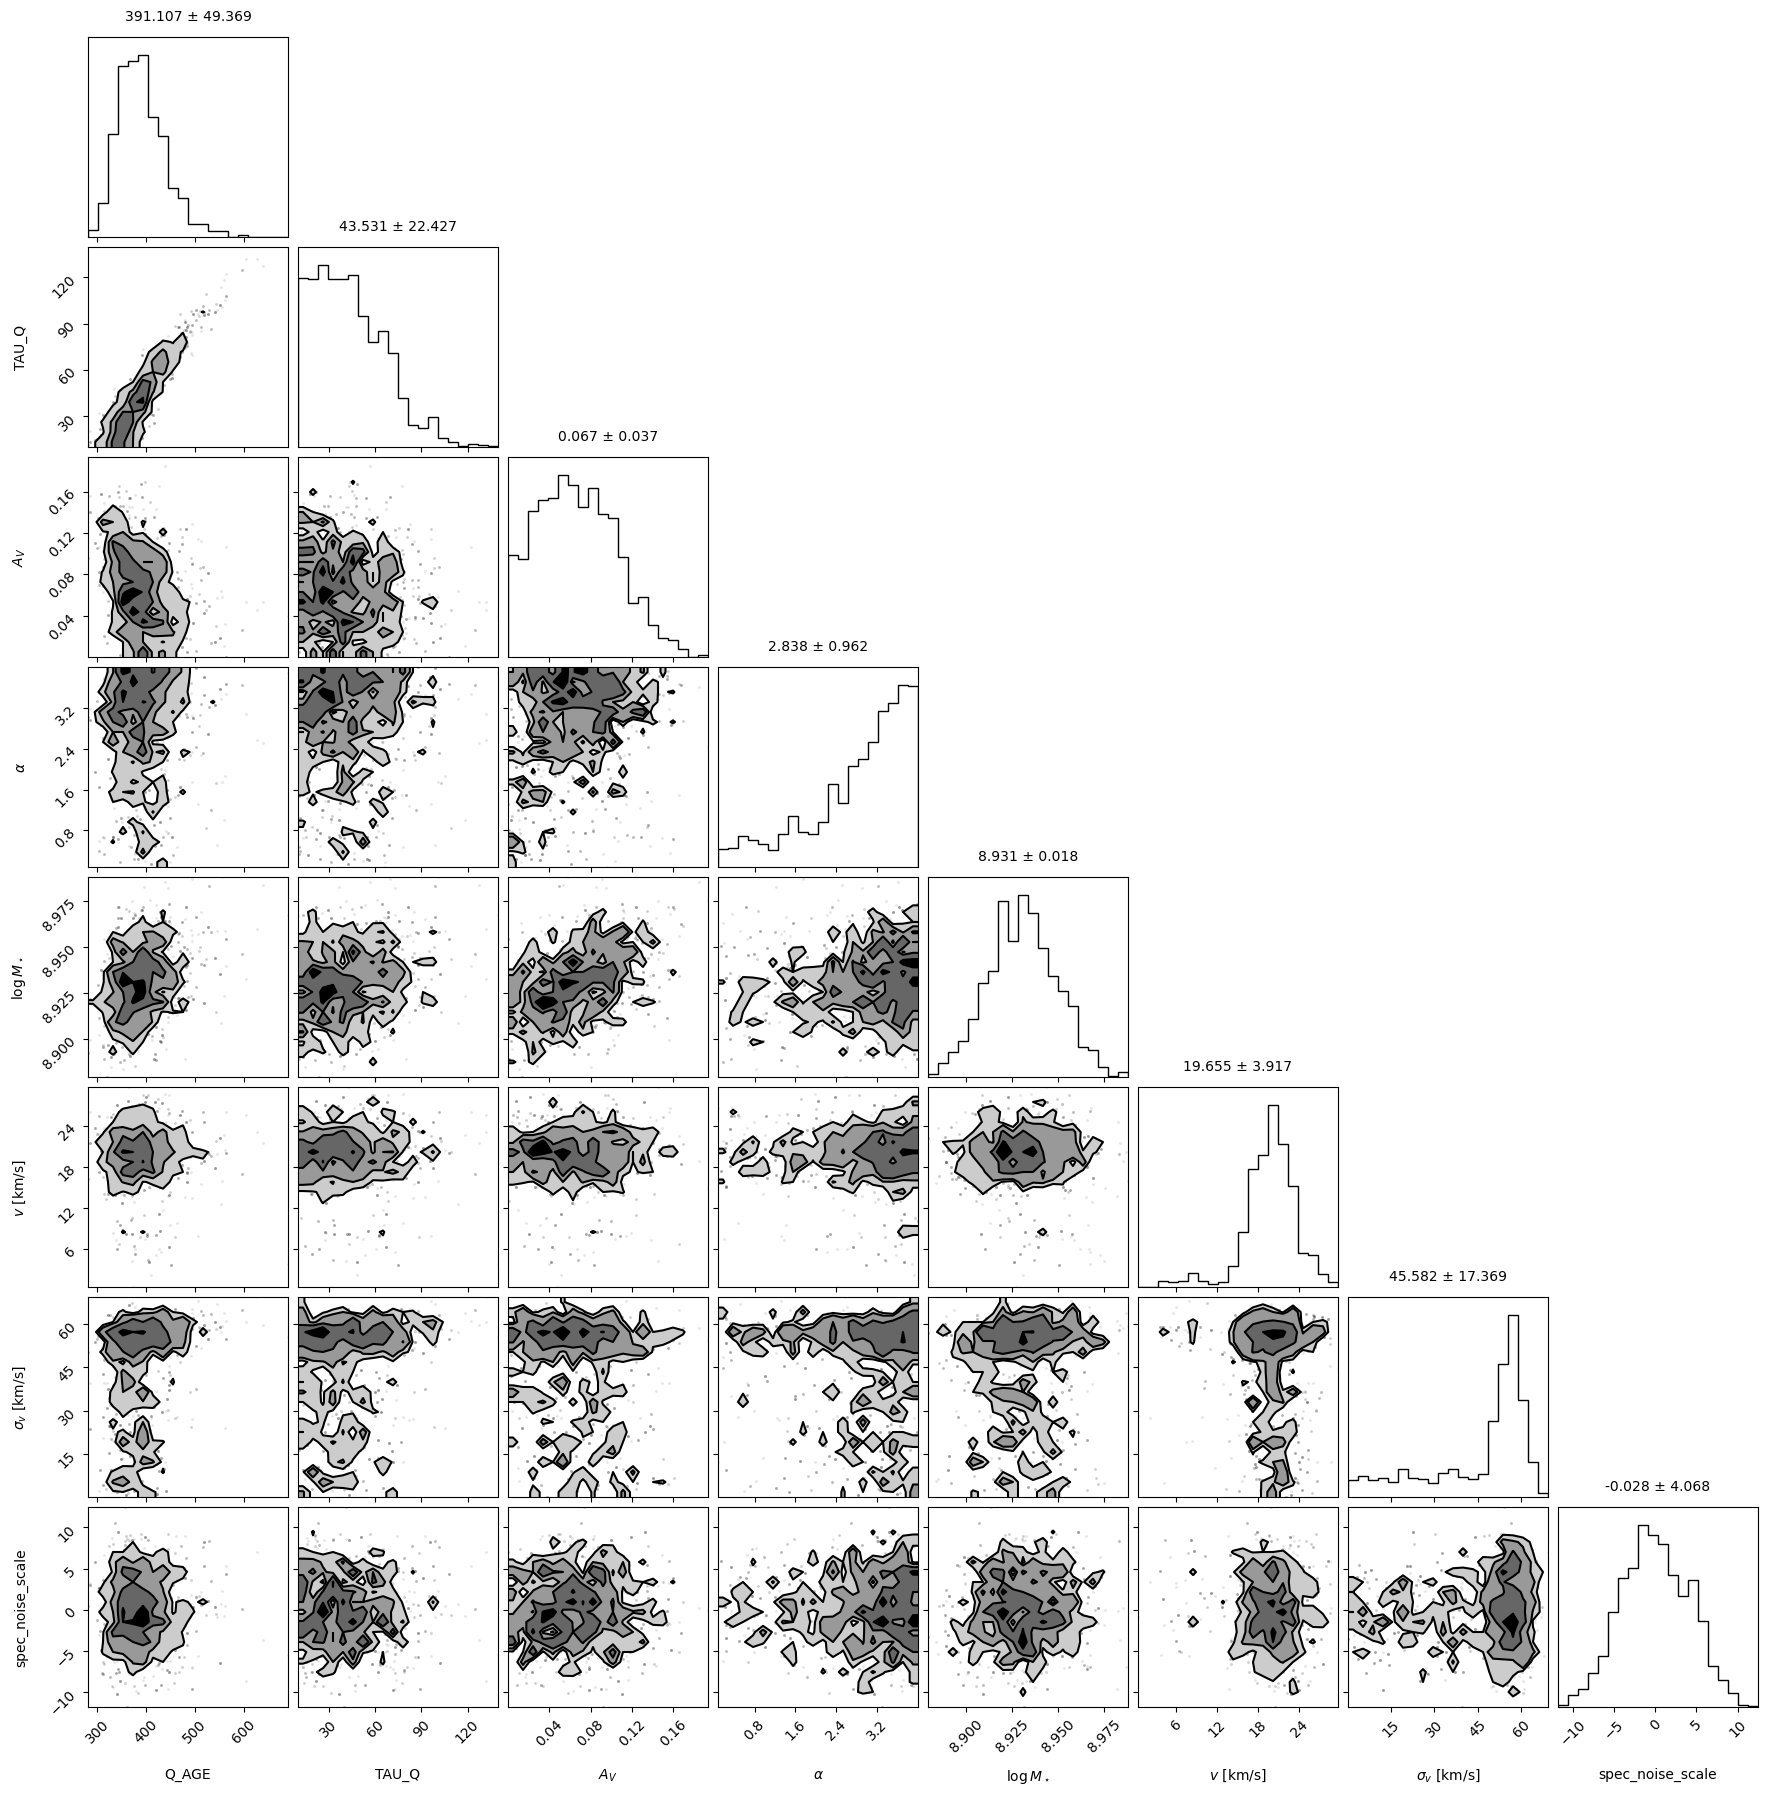

In [61]:
res_spec_3.cornerplot()

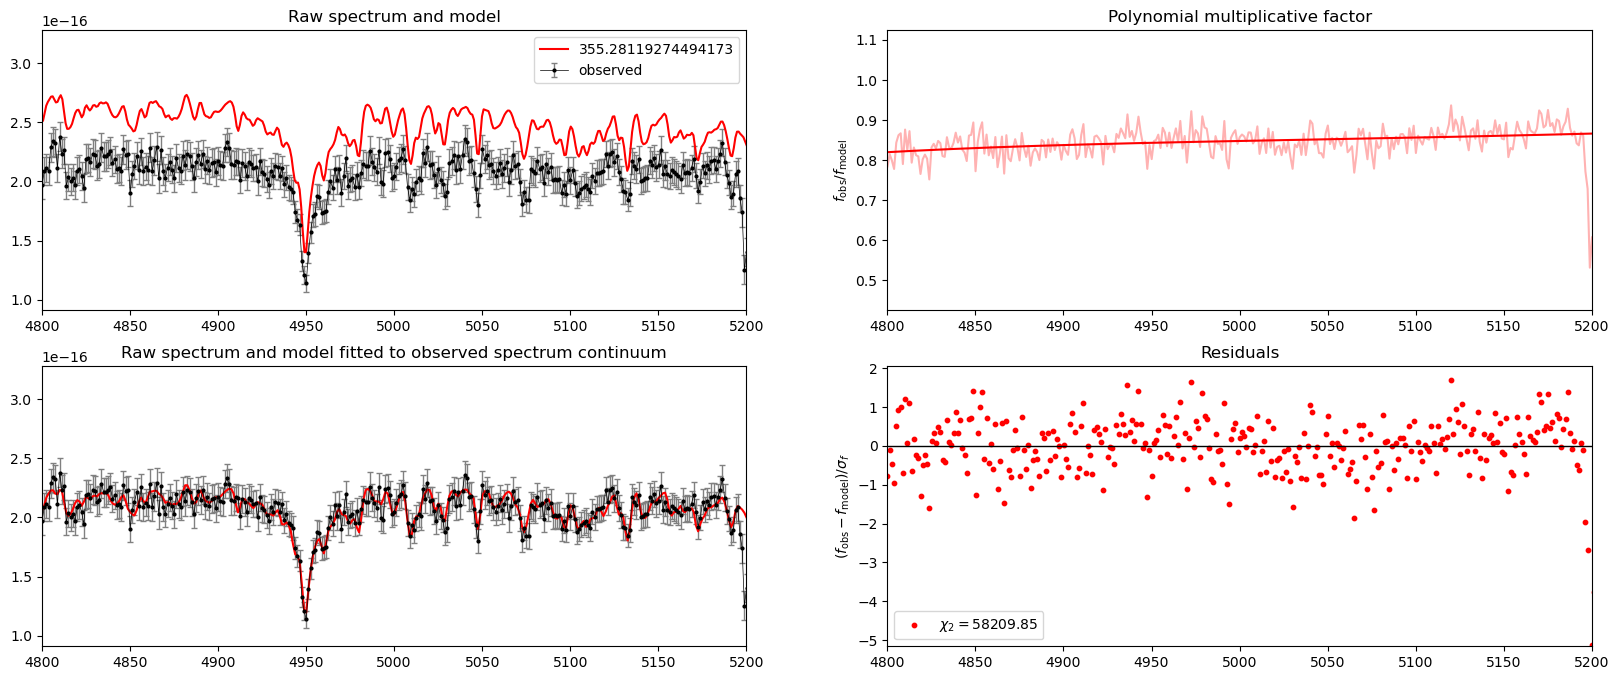

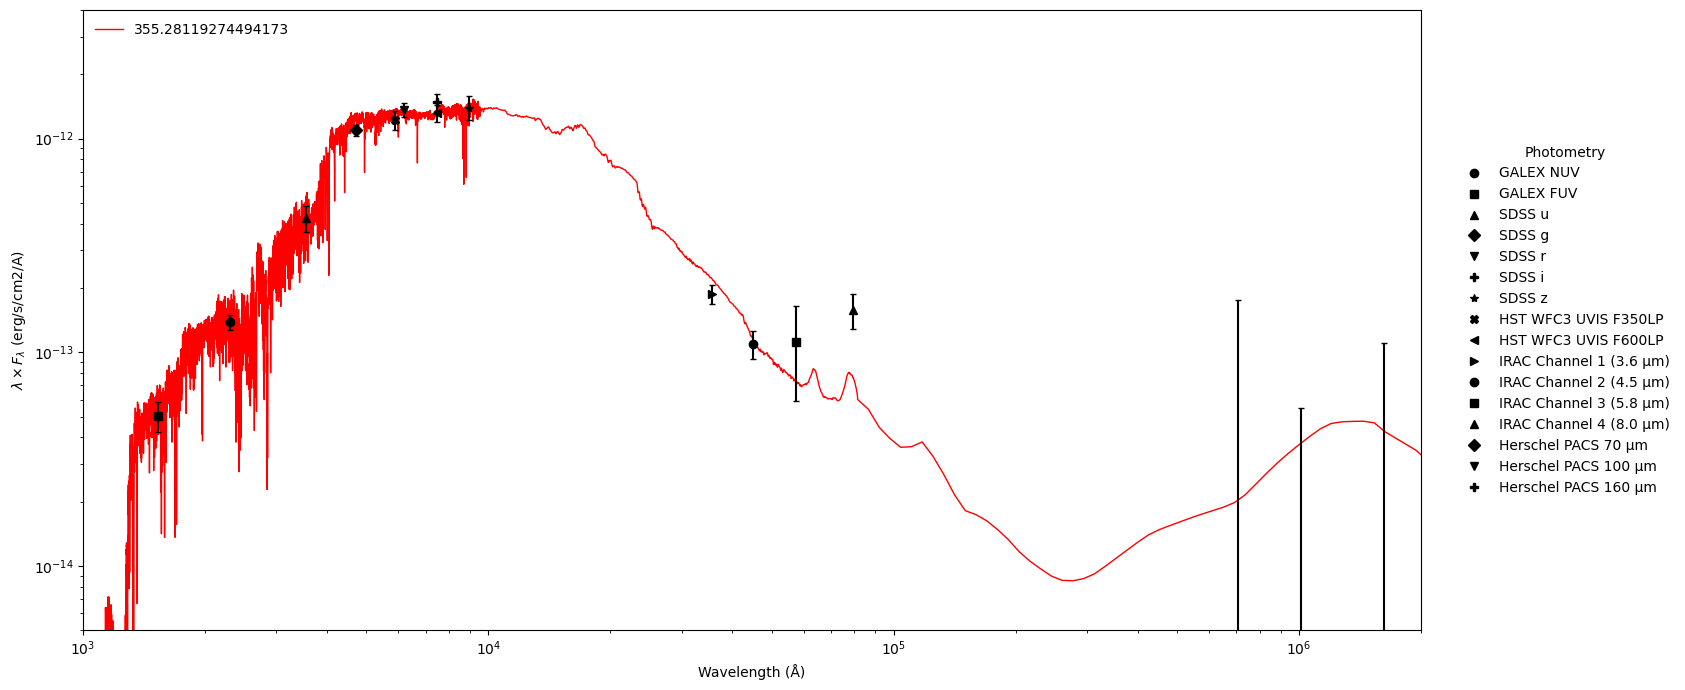

For model number:  1
GALEX NUV :  6.076477877569183
GALEX FUV :  6.644464603479014
SDSS u :  4.033718717032995
SDSS g :  3.4607036911114806
SDSS r :  2.804630398517837
SDSS i :  1.9064488848364793
SDSS z :  2.0048865811818146
HST WFC3 UVIS F350LP :  2.725715748652833
HST WFC3 UVIS F600LP :  2.545903533499065
IRAC Channel 1 (3.6 μm) :  1.1595615468205265
IRAC Channel 2 (4.5 μm) :  2.4707999520641915
IRAC Channel 3 (5.8 μm)  upper limit:  -0.30021377654820575
IRAC Channel 4 (8.0 μm) :  -3.967376274911227
Herschel PACS 70 μm  upper limit:  -0.7940733199236121
Herschel PACS 100 μm  upper limit:  -1.38342024782127
Herschel PACS 160 μm  upper limit:  -1.0462656772030219
TOTAL_PHOT:  28.341962238358086
TOTAL_SPEC:  58209.846339795076
TOTAL_PHOT+SPEC:  58238.188302033435




In [62]:
res_spec_3.fit_diagnostic(method='MAP',
        cumulative=False,
        winf = 4800,wsup=5200,
        spec_legend_pars='Q_AGE',
        color=['red','cyan'],
        figsize=(20,8),
        winf_phot=1e3,wsup_phot=2e6,
        ymin=0.5e-14,ymax=4e-12,)

# Region 4